# EDA de datasets médicaux Hugging Face

Ce notebook télécharge les datasets demandés dans `.cache/huggingface` à la racine du projet, puis lance une première analyse exploratoire.


## 1. Configuration

Cette section initialise le notebook : imports Python, cache Hugging Face, paramètres globaux et définition des datasets utilisés.

Points importants :
- `MediQAl` est chargé uniquement avec la config `mcqu`.
- Le `SFT` cible 5 000 paires train, plus 500 validation et 500 test.
- Le `DPO` se base uniquement sur `UltraMedical-Preference`.
- Le bloc RGPD est volontairement simple : Presidio avec regex simples, anonymisation par tags, puis contrôle final.


In [27]:
# Configuration globale du notebook : imports, cache HF et parametres de generation.

from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import Any

# Force the public Hugging Face Hub before importing datasets/huggingface_hub.
os.environ["HF_ENDPOINT"] = "https://huggingface.co"

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import Dataset, DatasetDict, IterableDataset, IterableDatasetDict, load_dataset
from IPython.display import display
from presidio_analyzer import RecognizerResult
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    return current


REPO_ROOT = find_repo_root()
CACHE_DIR = REPO_ROOT / ".cache" / "huggingface"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(CACHE_DIR)
os.environ["HF_DATASETS_CACHE"] = str(CACHE_DIR / "datasets")

# Datasets retenus pour le projet : SFT controle par source et DPO base sur UltraMedical-Preference.
DATASET_SPECS = {
    "MediQAl": {
        "repo_id": "ANR-MALADES/MediQAl",
        "configs": ["mcqu", "oeq"],
        "language": "fr",
    },
    "frenchmedmcqa": {"repo_id": "nthngdy/frenchmedmcqa", "language": "fr"},
    "MedQuad": {"repo_id": "keivalya/MedQuad-MedicalQnADataset", "language": "en"},
    "UltraMedicalPreference": {
        "repo_id": "TsinghuaC3I/UltraMedical-Preference",
        "language": "en",
        "path": "json",
        "data_files": {
            "train": "hf://datasets/TsinghuaC3I/UltraMedical-Preference/data/train.json",
            "validation": "hf://datasets/TsinghuaC3I/UltraMedical-Preference/data/dev.json",
        },
    },
}
TARGET_SFT_TRAIN_ROWS = 5_000
TARGET_SFT_VALIDATION_ROWS = 500
TARGET_SFT_TEST_ROWS = 500
TARGET_SFT_SPLIT_ROWS = {
    "train": TARGET_SFT_TRAIN_ROWS,
    "validation": TARGET_SFT_VALIDATION_ROWS,
    "test": TARGET_SFT_TEST_ROWS,
}
TARGET_SFT_ROWS = sum(TARGET_SFT_SPLIT_ROWS.values())
TARGET_DPO_ROWS = 5_000
TARGET_SFT_SOURCE_MIX = {
    "MediQAl/oeq": TARGET_SFT_ROWS // 4,
    "MedQuad": TARGET_SFT_ROWS // 4,
    "frenchmedmcqa": TARGET_SFT_ROWS // 4,
    "MediQAl/mcqu": TARGET_SFT_ROWS // 4,
}
DPO_SOURCE_FAMILY = "UltraMedicalPreference"
TEXT_COLUMN_HINTS = {
    "question", "answer", "instruction", "input", "output", "prompt", "response",
    "context", "query", "title", "content", "text", "chosen", "rejected"
}
SAMPLE_ROWS = 1_000
ANSWER_LABELS = ["A", "B", "C", "D", "E"]
ANSWER_COLUMNS = {label: f"answer_{label.lower()}" for label in ANSWER_LABELS}
CHOICE_PATTERN = re.compile(r"[A-E]|\d+")
# Configuration minimale Presidio : regex simples pour produire des entites puis anonymisation par tag.
PII_REGEX_PATTERNS = {
    "EMAIL": [re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")],
    "PHONE": [re.compile(r"(?:(?:\+|00)\d{1,3}[\s.-]?)?(?:\(?\d{1,4}\)?[\s.-]?){2,}\d{2,4}")],
    "URL": [re.compile(r"\b(?:https?://|www\.)\S+\b", re.IGNORECASE)],
    "DATE": [re.compile(r"\b(?:\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}|\d{1,2}\s+(?:janvier|fevrier|février|mars|avril|mai|juin|juillet|aout|août|septembre|octobre|novembre|decembre|décembre|january|february|march|april|may|june|july|august|september|october|november|december)\s+\d{2,4})\b", re.IGNORECASE)],
    "AGE": [re.compile(r"\b\d{1,3}\s*(?:ans|an|yo|years old|year old)\b", re.IGNORECASE)],
    "PERSON": [
        re.compile(r"\b(?:Monsieur|Madame|Mlle|Mme|Mr|Mrs|Miss|Dr|Doctor|Patient)\s+[A-Z][A-Za-z' -]{0,40}\b"),
        re.compile(r"\b(?:Monsieur|Madame|Mr|Mrs|Patient)\s+[A-Z]\.\b"),
    ],
}

print(f"Repo root          : {REPO_ROOT}")
print(f"Cache dir          : {CACHE_DIR}")
print(f"HF endpoint        : {os.environ['HF_ENDPOINT']}")
print(f"Dataset families   : {len(DATASET_SPECS)}")
print(f"Target SFT rows    : {TARGET_SFT_ROWS}")
print(f"Target SFT train   : {TARGET_SFT_TRAIN_ROWS}")
print(f"Target DPO rows    : {TARGET_DPO_ROWS}")
print(f"Target SFT splits  : {TARGET_SFT_SPLIT_ROWS}")
print(f"Target SFT mix     : {TARGET_SFT_SOURCE_MIX}")


Repo root          : /storage/user/zmxw1768/fine_tuning_oc
Cache dir          : /storage/user/zmxw1768/fine_tuning_oc/.cache/huggingface
HF endpoint        : https://huggingface.co
Dataset families   : 4
Target SFT rows    : 6000
Target SFT train   : 5000
Target DPO rows    : 5000
Target SFT splits  : {'train': 5000, 'validation': 500, 'test': 500}
Target SFT mix     : {'MediQAl/oeq': 1500, 'MedQuad': 1500, 'frenchmedmcqa': 1500, 'MediQAl/mcqu': 1500}


## 2. Helpers EDA

Cette partie contient les fonctions de support pour explorer les datasets : lecture des splits, échantillonnage, résumé de schéma et indicateurs de qualité.

Objectif : comprendre rapidement la structure des sources avant normalisation.


In [28]:
# Helpers EDA : lecture des splits, echantillonnage et mesures de qualite/schema.

def is_iterable_dataset(obj: Any) -> bool:
    return isinstance(obj, (IterableDataset, IterableDatasetDict))


def dataset_items(ds_obj: Any):
    if isinstance(ds_obj, (DatasetDict, IterableDatasetDict)):
        return ds_obj.items()
    return [("train", ds_obj)]


def safe_num_rows(split_ds: Any) -> int | None:
    return getattr(split_ds, "num_rows", None)


def infer_text_columns(columns: list[str]) -> list[str]:
    text_cols = []
    for col in columns:
        lowered = col.lower()
        if lowered in TEXT_COLUMN_HINTS or any(hint in lowered for hint in TEXT_COLUMN_HINTS):
            text_cols.append(col)
    return text_cols


# Convertit un split HF en DataFrame pour inspection rapide dans le notebook.
def sample_to_frame(split_ds: Any, limit: int = SAMPLE_ROWS) -> pd.DataFrame:
    if isinstance(split_ds, Dataset):
        size = min(limit, split_ds.num_rows)
        if size == 0:
            return pd.DataFrame()
        return split_ds.select(range(size)).to_pandas()

    rows = []
    for idx, row in enumerate(split_ds):
        if idx >= limit:
            break
        rows.append(row)
    return pd.DataFrame(rows)


def text_stats(frame: pd.DataFrame, dataset_name: str, split_name: str) -> list[dict[str, Any]]:
    if frame.empty:
        return []

    rows = []
    for col in infer_text_columns(frame.columns.tolist()):
        series = frame[col].dropna().astype(str)
        if series.empty:
            continue
        rows.append(
            {
                "dataset": dataset_name,
                "split": split_name,
                "column": col,
                "sample_size": int(series.shape[0]),
                "avg_chars": round(series.str.len().mean(), 2),
                "median_chars": round(series.str.len().median(), 2),
                "avg_words": round(series.str.split().str.len().mean(), 2),
                "unique_ratio": round(series.nunique() / max(len(series), 1), 4),
            }
        )
    return rows


# Resume le schema de chaque split pour comparer les datasets entre eux.
def schema_rows(ds_obj: Any, dataset_name: str) -> list[dict[str, Any]]:
    rows = []
    for split_name, split_ds in dataset_items(ds_obj):
        features = getattr(split_ds, "features", {}) or {}
        rows.append(
            {
                "dataset": dataset_name,
                "split": split_name,
                "num_rows": safe_num_rows(split_ds),
                "num_columns": len(split_ds.column_names),
                "columns": ", ".join(split_ds.column_names),
                "text_columns": ", ".join(infer_text_columns(split_ds.column_names)),
                "feature_types": ", ".join(f"{col}: {spec}" for col, spec in features.items()),
            }
        )
    return rows


# Donne des signaux simples de qualite sur un echantillon : doublons et valeurs manquantes.
def quality_rows(frame: pd.DataFrame, dataset_name: str, split_name: str) -> dict[str, Any]:
    if frame.empty:
        return {
            "dataset": dataset_name,
            "split": split_name,
            "sample_rows": 0,
            "sample_duplicate_rows": 0,
            "sample_missing_cells": 0,
            "sample_missing_ratio": 0.0,
        }

    total_cells = max(frame.shape[0] * max(frame.shape[1], 1), 1)
    return {
        "dataset": dataset_name,
        "split": split_name,
        "sample_rows": int(frame.shape[0]),
        "sample_duplicate_rows": int(frame.astype(str).duplicated().sum()),
        "sample_missing_cells": int(frame.isna().sum().sum()),
        "sample_missing_ratio": round(frame.isna().sum().sum() / total_cells, 4),
    }


def sorted_frame(rows: list[dict[str, Any]], sort_by: list[str]) -> pd.DataFrame:
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    return frame.sort_values(sort_by).reset_index(drop=True)

## 3. Helpers Préparation Entraînement

Cette section regroupe la logique métier du notebook :
- chargement des sources,
- normalisation vers un format commun,
- génération du dataset `SFT`,
- génération du dataset `DPO`,
- anonymisation Presidio simplifiée et contrôle final.


In [29]:
# Helpers entrainement : chargement, normalisation, construction SFT/DPO et bloc RGPD Presidio simplifie.

# Prepare les jobs de chargement a partir de la configuration declarative ci-dessus.
def build_load_jobs() -> list[dict[str, Any]]:
    jobs: list[dict[str, Any]] = []
    for source_family, spec in DATASET_SPECS.items():
        configs = spec.get("configs") or [spec.get("config")]
        for config in configs:
            label = f"{source_family}/{config}" if config else source_family
            jobs.append(
                {
                    "label": label,
                    "source_family": source_family,
                    "repo_id": spec["repo_id"],
                    "config": config,
                    "language": spec["language"],
                    "path": spec.get("path"),
                    "data_files": spec.get("data_files"),
                }
            )
    return jobs


def dataset_label(job: dict[str, Any]) -> str:
    return str(job["label"])


def load_dataset_job(job: dict[str, Any], cache_dir: str | None = None):
    path = job.get("path") or job["repo_id"]
    config = job.get("config")
    kwargs = {"cache_dir": cache_dir}
    if job.get("data_files"):
        kwargs["data_files"] = job["data_files"]
    if config:
        return load_dataset(path, config, **kwargs)
    return load_dataset(path, **kwargs)


def safe_str(value: Any) -> str | None:
    if value is None:
        return None
    try:
        if not isinstance(value, (dict, list, tuple, set)) and pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    text = str(value).strip()
    return text or None


def parse_choice_codes(value: Any) -> list[str]:
    if value is None or isinstance(value, bool):
        return []

    if isinstance(value, int):
        if 0 <= value < len(ANSWER_LABELS):
            return [ANSWER_LABELS[value]]
        return []

    if isinstance(value, float):
        if math.isnan(value):
            return []
        integer_value = int(value)
        if 0 <= integer_value < len(ANSWER_LABELS):
            return [ANSWER_LABELS[integer_value]]
        return []

    ordered_codes: list[str] = []
    for token in CHOICE_PATTERN.findall(str(value).upper()):
        if token.isdigit():
            idx = int(token)
            if 0 <= idx < len(ANSWER_LABELS):
                code = ANSWER_LABELS[idx]
            else:
                continue
        else:
            code = token

        if code not in ordered_codes:
            ordered_codes.append(code)
    return ordered_codes


def format_choice_labels(value: Any) -> str | None:
    codes = parse_choice_codes(value)
    if not codes:
        return None
    return ",".join(codes)


def format_choice_indices(value: Any) -> str | None:
    codes = parse_choice_codes(value)
    if not codes:
        return None
    return ",".join(str(ANSWER_LABELS.index(code) + 1) for code in codes)


def build_option_map(row: dict[str, Any]) -> dict[str, str]:
    option_map: dict[str, str] = {}
    for label, column in ANSWER_COLUMNS.items():
        answer_text = safe_str(row.get(column))
        if answer_text:
            option_map[label] = answer_text
    return option_map


def build_options(row: dict[str, Any]) -> list[str]:
    option_map = build_option_map(row)
    return [f"{label}. {text}" for label, text in option_map.items()]


def resolve_choice_answer(row: dict[str, Any]) -> str | None:
    option_map = build_option_map(row)
    codes = parse_choice_codes(row.get("correct_answers"))
    if not codes:
        return None

    resolved = []
    for code in codes:
        option_text = option_map.get(code)
        if option_text:
            resolved.append(f"{code}. {option_text}")
    if not resolved:
        return None
    return "\n".join(resolved)


def message_content(message: Any) -> str | None:
    if isinstance(message, dict):
        return safe_str(message.get("content") or message.get("value") or message.get("text"))
    return safe_str(message)


def message_role(message: Any) -> str | None:
    if not isinstance(message, dict):
        return None
    return safe_str(message.get("role") or message.get("from"))


def extract_assistant_reply(messages: Any) -> str | None:
    if isinstance(messages, (str, dict)):
        return message_content(messages)
    if not isinstance(messages, list):
        return safe_str(messages)

    for message in reversed(messages):
        role = (message_role(message) or "").lower()
        if role in {"assistant", "gpt", "model"}:
            return message_content(message)
    for message in reversed(messages):
        content = message_content(message)
        if content:
            return content
    return None


def question_with_context(question: str | None, context: str | None) -> str | None:
    question = safe_str(question)
    context = safe_str(context)
    if question and context:
        return f"{context}\n\nQuestion: {question}"
    return question or context


# Normalise chaque source vers un format commun exploitable par les pipelines SFT et DPO.
def normalize_record(
    row: dict[str, Any],
    *,
    row_idx: int,
    split_name: str,
    job: dict[str, Any],
) -> dict[str, Any] | None:
    source_family = job["source_family"]
    question: str | None = None
    answer: str | None = None
    answer_key: str | None = None
    answer_index: str | None = None
    rejected_answer: str | None = None
    context: str | None = None
    options: list[str] = []
    task_type: str | None = None
    topic: str | None = None
    question_type: str | None = None

    if source_family == "MediQAl":
        config = safe_str(job.get("config"))
        context = safe_str(row.get("clinical_case"))
        question = safe_str(row.get("question"))
        topic = safe_str(row.get("medical_subject"))
        question_type = safe_str(row.get("question_type"))
        if config == "oeq":
            answer = safe_str(row.get("answer"))
            task_type = "open_qa"
        else:
            options = build_options(row)
            answer = resolve_choice_answer(row)
            answer_key = format_choice_labels(row.get("correct_answers"))
            answer_index = format_choice_indices(row.get("correct_answers"))
            task_type = "mcq_single"
    elif source_family == "frenchmedmcqa":
        question = safe_str(row.get("question"))
        options = build_options(row)
        answer = resolve_choice_answer(row)
        answer_key = format_choice_labels(row.get("correct_answers"))
        answer_index = format_choice_indices(row.get("correct_answers"))
        task_type = "mcq_single"
    elif source_family == "MedQuad":
        question = safe_str(row.get("Question"))
        answer = safe_str(row.get("Answer"))
        topic = safe_str(row.get("qtype"))
        task_type = "open_qa"
    elif source_family == "UltraMedicalPreference":
        question = safe_str(row.get("prompt"))
        answer = extract_assistant_reply(row.get("chosen"))
        rejected_answer = extract_assistant_reply(row.get("rejected"))
        topic = safe_str(row.get("label_type"))
        task_type = "preferred_response"
    else:
        return None

    if not question or not answer:
        return None

    source_id = safe_str(row.get("id")) or safe_str(row.get("prompt_id"))
    if not source_id:
        source_id = f"{dataset_label(job)}::{split_name}::{row_idx}"

    return {
        "dataset": dataset_label(job),
        "source_family": source_family,
        "source_repo_id": job["repo_id"],
        "source_config": job.get("config"),
        "split": split_name,
        "source_id": source_id,
        "language": job["language"],
        "task_type": task_type,
        "topic": topic,
        "question_type": question_type,
        "context": context,
        "question": question,
        "question_with_context": question_with_context(question, context),
        "options": options,
        "options_text": "\n".join(options),
        "answer": answer,
        "answer_key": answer_key,
        "answer_index": answer_index,
        "rejected_answer": rejected_answer,
    }


def normalize_all_datasets(
    loaded_datasets: dict[str, Any],
    dataset_job_index: dict[str, dict[str, Any]],
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for dataset_name, ds_obj in loaded_datasets.items():
        job = dataset_job_index[dataset_name]
        for split_name, split_ds in dataset_items(ds_obj):
            for row_idx, row in enumerate(split_ds):
                normalized = normalize_record(
                    row,
                    row_idx=row_idx,
                    split_name=split_name,
                    job=job,
                )
                if normalized is not None:
                    rows.append(normalized)
    return rows


def _build_section(title_fr: str, title_en: str, value: str | None, language: str) -> str:
    value = safe_str(value)
    if not value:
        return ""
    title = title_fr if language == "fr" else title_en
    return f"{title}\n{value}"


# Transforme une ligne normalisee en prompt d'instruction pour le fine-tuning supervise.
def build_instruction(record: dict[str, Any]) -> str:
    language = record["language"]
    context_block = _build_section("Contexte clinique :", "Clinical context:", record.get("context"), language)
    question_block = _build_section("Question :", "Question:", record.get("question"), language)
    options_block = _build_section("Options :", "Options:", record.get("options_text"), language)
    blocks = [block for block in [context_block, question_block, options_block] if block]

    if record["task_type"] == "mcq_single":
        intro = (
            "Réponds à la question médicale suivante en donnant uniquement l'option correcte avec sa lettre et son texte."
            if language == "fr"
            else "Answer the following medical question with only the correct option, including its letter and text."
        )
    else:
        intro = (
            "Réponds à la demande médicale suivante de manière claire, factuelle et structurée."
            if language == "fr"
            else "Answer the following medical request clearly, factually, and in a structured way."
        )

    return "\n\n".join([intro, *blocks]).strip()


# Construit les paires instruction/reponse qui serviront au dataset SFT final.
def build_sft_candidate_frame(normalized_df: pd.DataFrame) -> pd.DataFrame:
    if normalized_df.empty:
        return pd.DataFrame()

    rows = []
    for record in normalized_df.to_dict(orient="records"):
        if record["source_family"] == DPO_SOURCE_FAMILY:
            continue

        rows.append(
            {
                "dataset": record["dataset"],
                "source_family": record["source_family"],
                "source_repo_id": record["source_repo_id"],
                "source_config": record["source_config"],
                "split": record["split"],
                "source_id": record["source_id"],
                "language": record["language"],
                "task_type": record["task_type"],
                "topic": record.get("topic"),
                "instruction": build_instruction(record),
                "response": record["answer"],
                "answer_key": record.get("answer_key"),
                "answer_index": record.get("answer_index"),
            }
        )

    frame = pd.DataFrame(rows)
    return deduplicate_text_pairs(frame, ["instruction", "response"])


# Construit les paires preferees/rejetees pour le DPO a partir d'UltraMedical-Preference uniquement.
def build_dpo_candidate_frame(normalized_df: pd.DataFrame) -> pd.DataFrame:
    if normalized_df.empty:
        return pd.DataFrame()

    rows = []
    for record in normalized_df.to_dict(orient="records"):
        if record["source_family"] != DPO_SOURCE_FAMILY:
            continue

        rejected_answer = safe_str(record.get("rejected_answer"))
        if not rejected_answer:
            continue

        rows.append(
            {
                "dataset": record["dataset"],
                "source_family": record["source_family"],
                "source_repo_id": record["source_repo_id"],
                "source_config": record["source_config"],
                "split": record["split"],
                "source_id": record["source_id"],
                "language": record["language"],
                "task_type": record["task_type"],
                "topic": record.get("topic"),
                "prompt": build_instruction(record),
                "chosen": record["answer"],
                "rejected": rejected_answer,
            }
        )

    frame = pd.DataFrame(rows)
    return deduplicate_text_pairs(frame, ["prompt", "chosen", "rejected"])


def harmonize_sample_frame(dataset_name: str, frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty or "correct_answers" not in frame.columns:
        return frame

    preview = frame.copy()
    preview["correct_answers_raw"] = preview["correct_answers"]
    preview["correct_answers"] = preview["correct_answers"].map(format_choice_labels)
    return preview


def deduplicate_text_pairs(frame: pd.DataFrame, text_columns: list[str]) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    clean = frame.copy()
    for column in text_columns:
        clean[column] = clean[column].fillna("").astype(str).str.strip()
    clean = clean[(clean[text_columns] != "").all(axis=1)]
    clean = clean.drop_duplicates(subset=text_columns)
    return clean.reset_index(drop=True)


# Bloc RGPD Presidio simplifie : on detecte par regex puis on anonymise avec Presidio.
PRESIDIO_ANONYMIZER = AnonymizerEngine()
PRESIDIO_OPERATORS = {
    entity_type: OperatorConfig("replace", {"new_value": f"[{entity_type}]"})
    for entity_type in PII_REGEX_PATTERNS
}


def analyze_pii_with_presidio(text: str | None) -> list[RecognizerResult]:
    text = safe_str(text)
    if not text:
        return []

    results: list[RecognizerResult] = []
    for entity_type, patterns in PII_REGEX_PATTERNS.items():
        for pattern in patterns:
            for match in pattern.finditer(text):
                results.append(
                    RecognizerResult(
                        entity_type=entity_type,
                        start=match.start(),
                        end=match.end(),
                        score=0.8,
                    )
                )

    results.sort(key=lambda item: (item.start, item.end))
    return results


def anonymize_text_with_presidio(text: str | None) -> str | None:
    text = safe_str(text)
    if not text:
        return text

    analyzer_results = analyze_pii_with_presidio(text)
    if not analyzer_results:
        return text

    return PRESIDIO_ANONYMIZER.anonymize(
        text=text,
        analyzer_results=analyzer_results,
        operators=PRESIDIO_OPERATORS,
    ).text


def anonymize_dataframe_with_presidio(frame: pd.DataFrame, text_columns: list[str]) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    anonymized = frame.copy()
    for column in text_columns:
        if column in anonymized.columns:
            anonymized[column] = anonymized[column].map(anonymize_text_with_presidio)
    return anonymized


def build_pii_report(frame: pd.DataFrame, text_columns: list[str], *, dataset_name: str) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    if frame.empty:
        return pd.DataFrame([{
            "dataset_name": dataset_name,
            "column": None,
            "entity_type": None,
            "matches": 0,
            "rows_flagged": 0,
        }])

    for column in text_columns:
        if column not in frame.columns:
            continue

        counts: dict[str, dict[str, int]] = {}
        series = frame[column].fillna("").astype(str)
        for text in series:
            detected = analyze_pii_with_presidio(text)
            flagged_entities = set()
            for item in detected:
                bucket = counts.setdefault(item.entity_type, {"matches": 0, "rows_flagged": 0})
                bucket["matches"] += 1
                flagged_entities.add(item.entity_type)
            for entity_type in flagged_entities:
                counts[entity_type]["rows_flagged"] += 1

        for entity_type, metrics in counts.items():
            rows.append(
                {
                    "dataset_name": dataset_name,
                    "column": column,
                    "entity_type": entity_type,
                    "matches": metrics["matches"],
                    "rows_flagged": metrics["rows_flagged"],
                }
            )

    if not rows:
        return pd.DataFrame([{
            "dataset_name": dataset_name,
            "column": None,
            "entity_type": None,
            "matches": 0,
            "rows_flagged": 0,
        }])
    return pd.DataFrame(rows).sort_values(["dataset_name", "column", "entity_type"]).reset_index(drop=True)


def sample_source_quota_frame(
    frame: pd.DataFrame,
    *,
    source_targets: dict[str, int],
    target_rows: int,
    seed: int = 42,
) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    sampled_parts: list[pd.DataFrame] = []
    used_indices: set[int] = set()
    allowed_sources = set(source_targets)

    for source_name, target in source_targets.items():
        source_pool = frame[frame["dataset"] == source_name]
        take = min(len(source_pool), max(target, 0))
        if take <= 0:
            continue
        sample = source_pool.sample(n=take, random_state=seed)
        sampled_parts.append(sample)
        used_indices.update(sample.index.tolist())

    sampled = pd.concat(sampled_parts, ignore_index=False) if sampled_parts else frame.iloc[0:0].copy()
    if len(sampled) < target_rows:
        remaining_pool = frame[
            frame["dataset"].isin(allowed_sources) & ~frame.index.isin(used_indices)
        ]
        refill = min(target_rows - len(sampled), len(remaining_pool))
        if refill > 0:
            sampled = pd.concat(
                [sampled, remaining_pool.sample(n=refill, random_state=seed)],
                ignore_index=False,
            )

    return sampled.head(target_rows).sort_values(["task_type", "dataset", "split", "source_id"]).reset_index(drop=True)


def split_sft_frame(
    frame: pd.DataFrame,
    *,
    split_targets: dict[str, int] | None = None,
    stratify_columns: list[str] | None = None,
    seed: int = 42,
) -> dict[str, pd.DataFrame]:
    split_targets = split_targets or TARGET_SFT_SPLIT_ROWS
    split_ratios = {name: target / sum(split_targets.values()) for name, target in split_targets.items()}
    splits = {name: [] for name in split_targets}
    if frame.empty:
        return {name: frame.copy() for name in split_targets}

    target_sum = sum(split_targets.values())
    if target_sum != len(frame):
        raise ValueError(f"Les split targets SFT doivent sommer a {len(frame)}, obtenu: {target_sum}")

    stratify_columns = stratify_columns or ["task_type", "dataset", "language"]
    stratify_columns = [column for column in stratify_columns if column in frame.columns]
    grouped = frame.groupby(stratify_columns, dropna=False) if stratify_columns else [(None, frame)]

    for _, group in grouped:
        shuffled = group.sample(frac=1, random_state=seed)
        n_rows = len(shuffled)
        cursor = 0
        remaining = n_rows
        for split_name, ratio in split_ratios.items():
            if split_name == list(split_ratios)[-1]:
                take = remaining
            else:
                take = round(n_rows * ratio)
                take = min(max(take, 0), remaining)
            if take > 0:
                splits[split_name].append(shuffled.iloc[cursor:cursor + take])
            cursor += take
            remaining -= take

    result = {
        name: pd.concat(parts, ignore_index=False) if parts else frame.iloc[0:0].copy()
        for name, parts in splits.items()
    }

    for split_name, target in split_targets.items():
        while len(result[split_name]) < target:
            donor_name = next(
                (name for name, split_frame in result.items() if len(split_frame) > split_targets[name]),
                None,
            )
            if donor_name is None:
                break
            take = min(target - len(result[split_name]), len(result[donor_name]) - split_targets[donor_name])
            moved = result[donor_name].sample(n=take, random_state=seed)
            result[split_name] = pd.concat([result[split_name], moved], ignore_index=False)
            result[donor_name] = result[donor_name].drop(index=moved.index)

    return {
        name: split_frame.sort_values(["task_type", "dataset", "split", "source_id"]).reset_index(drop=True)
        for name, split_frame in result.items()
    }


def sample_balanced_frame(
    frame: pd.DataFrame,
    *,
    target_rows: int,
    language_targets: dict[str, int] | None = None,
    seed: int = 42,
) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    if language_targets is None:
        take = min(target_rows, len(frame))
        return frame.sample(n=take, random_state=seed).sort_values(["language", "source_family", "split", "source_id"]).reset_index(drop=True)

    sampled_parts: list[pd.DataFrame] = []
    used_indices: set[int] = set()

    for language, target in language_targets.items():
        language_pool = frame[frame["language"] == language]
        if language_pool.empty or target <= 0:
            continue

        families = sorted(language_pool["source_family"].dropna().unique().tolist())
        if not families:
            continue

        base_quota = target // len(families)
        remainder = target % len(families)
        shortfall = 0

        for idx, family in enumerate(families):
            quota = base_quota + (1 if idx < remainder else 0)
            family_pool = language_pool[language_pool["source_family"] == family]
            take = min(len(family_pool), quota)
            if take > 0:
                sample = family_pool.sample(n=take, random_state=seed)
                sampled_parts.append(sample)
                used_indices.update(sample.index.tolist())
            shortfall += quota - take

        if shortfall > 0:
            remaining_pool = language_pool.loc[~language_pool.index.isin(used_indices)]
            refill = min(shortfall, len(remaining_pool))
            if refill > 0:
                sample = remaining_pool.sample(n=refill, random_state=seed)
                sampled_parts.append(sample)
                used_indices.update(sample.index.tolist())

    sampled = pd.concat(sampled_parts, ignore_index=False) if sampled_parts else frame.iloc[0:0].copy()

    if len(sampled) < target_rows:
        remaining_pool = frame.loc[~frame.index.isin(used_indices)]
        refill = min(target_rows - len(sampled), len(remaining_pool))
        if refill > 0:
            sampled = pd.concat(
                [sampled, remaining_pool.sample(n=refill, random_state=seed)],
                ignore_index=False,
            )

    return sampled.head(target_rows).sort_values(["language", "source_family", "split", "source_id"]).reset_index(drop=True)


# Orchestre tout le pipeline notebook : normalisation, echantillonnage SFT/DPO et validation RGPD.
def build_training_artifacts(
    loaded_datasets: dict[str, Any],
    dataset_job_index: dict[str, dict[str, Any]],
    *,
    sft_target_rows: int = TARGET_SFT_ROWS,
    dpo_target_rows: int = TARGET_DPO_ROWS,
    sft_source_targets: dict[str, int] | None = None,
) -> dict[str, pd.DataFrame]:
    normalized_df = pd.DataFrame(normalize_all_datasets(loaded_datasets, dataset_job_index))
    if normalized_df.empty:
        empty = pd.DataFrame()
        return {
            "normalized_df": empty,
            "sft_candidates_df": empty,
            "sft_5000_df": empty,
            "sft_train_df": empty,
            "sft_validation_df": empty,
            "sft_test_df": empty,
            "dpo_candidates_df": empty,
            "dpo_5000_df": empty,
            "rgpd_report_df": empty,
        }

    sft_candidates_df = build_sft_candidate_frame(normalized_df)
    sft_5000_df = sample_source_quota_frame(
        sft_candidates_df,
        source_targets=sft_source_targets or TARGET_SFT_SOURCE_MIX,
        target_rows=sft_target_rows,
    )
    sft_split_frames = split_sft_frame(sft_5000_df, split_targets=TARGET_SFT_SPLIT_ROWS)
    dpo_candidates_df = build_dpo_candidate_frame(normalized_df)
    dpo_5000_df = sample_balanced_frame(
        dpo_candidates_df,
        target_rows=dpo_target_rows,
        language_targets={"en": dpo_target_rows},
    )
    sft_5000_df = anonymize_dataframe_with_presidio(sft_5000_df, ["instruction", "response"])
    sft_train_df = anonymize_dataframe_with_presidio(sft_split_frames["train"], ["instruction", "response"])
    sft_validation_df = anonymize_dataframe_with_presidio(sft_split_frames["validation"], ["instruction", "response"])
    sft_test_df = anonymize_dataframe_with_presidio(sft_split_frames["test"], ["instruction", "response"])
    dpo_5000_df = anonymize_dataframe_with_presidio(dpo_5000_df, ["prompt", "chosen", "rejected"])

    rgpd_report_df = pd.concat(
        [
            build_pii_report(sft_5000_df, ["instruction", "response"], dataset_name="sft_5000"),
            build_pii_report(dpo_5000_df, ["prompt", "chosen", "rejected"], dataset_name="dpo_5000"),
        ],
        ignore_index=True,
    )

    return {
        "normalized_df": normalized_df,
        "sft_candidates_df": sft_candidates_df,
        "sft_5000_df": sft_5000_df,
        "sft_train_df": sft_train_df,
        "sft_validation_df": sft_validation_df,
        "sft_test_df": sft_test_df,
        "dpo_candidates_df": dpo_candidates_df,
        "dpo_5000_df": dpo_5000_df,
        "rgpd_report_df": rgpd_report_df,
    }


## 4. Chargement des Datasets

Cette cellule télécharge et charge les sources brutes dans le cache local Hugging Face.

Le résultat attendu est un dictionnaire `loaded_datasets` prêt pour l'EDA et la préparation des jeux d'entraînement.


In [30]:
# Charge toutes les sources brutes dans le cache local Hugging Face.

loaded_datasets: dict[str, Any] = {}
load_errors: dict[str, str] = {}
dataset_jobs = build_load_jobs()
dataset_job_index = {dataset_label(job): job for job in dataset_jobs}

# Une source = un job de chargement ; MediQAl est force sur la config mcqu.
for job in dataset_jobs:
    label = dataset_label(job)
    repo_id = job["repo_id"]
    config = job.get("config")
    config_suffix = f" ({config})" if config else ""
    print(f"Chargement de {repo_id}{config_suffix} ...")
    try:
        loaded_datasets[label] = load_dataset_job(job, cache_dir=str(CACHE_DIR))
        print(f"  OK: {label}")
    except Exception as exc:
        load_errors[label] = f"{type(exc).__name__}: {exc}"
        print(f"  ECHEC: {load_errors[label]}")

print()
print(f"Sources chargees : {len(loaded_datasets)} / {len(dataset_jobs)}")
print(f"Familles actives : {len({job['source_family'] for job in dataset_jobs})}")
if load_errors:
    print("Erreurs detectees:")
    for name, error in load_errors.items():
        print(f"- {name}: {error}")


Chargement de ANR-MALADES/MediQAl (mcqu) ...
  OK: MediQAl/mcqu
Chargement de ANR-MALADES/MediQAl (oeq) ...
  OK: MediQAl/oeq
Chargement de nthngdy/frenchmedmcqa ...
  OK: frenchmedmcqa
Chargement de keivalya/MedQuad-MedicalQnADataset ...
  OK: MedQuad
Chargement de TsinghuaC3I/UltraMedical-Preference ...
  OK: UltraMedicalPreference

Sources chargees : 5 / 5
Familles actives : 4


## 5. Analyse Exploratoire

Les cellules suivantes comparent les datasets chargés : schéma, qualité, colonnes textuelles et aperçu d'exemples.

But : valider que les sources sont cohérentes avant de construire `SFT` et `DPO`.


In [31]:
schema_summary_rows = [
    row
    for dataset_name, ds_obj in loaded_datasets.items()
    for row in schema_rows(ds_obj, dataset_name)
]
schema_summary = sorted_frame(schema_summary_rows, ["dataset", "split"])

schema_summary

,dataset,split,num_rows,num_columns,columns,text_columns,feature_types
0,MedQuad,train,16407,3,"qtype, Question, Answer","Question, Answer","qtype: Value('string'), Question: Value('string'), Answer: Value('string')"
1,MediQAl/mcqu,test,4343,12,"id, clinical_case, question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, task, medical_subjec...","question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, question_type","id: Value('string'), clinical_case: Value('string'), question: Value('string'), answer_a: Value('string'), answer_b:..."
2,MediQAl/mcqu,train,10113,12,"id, clinical_case, question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, task, medical_subjec...","question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, question_type","id: Value('string'), clinical_case: Value('string'), question: Value('string'), answer_a: Value('string'), answer_b:..."
3,MediQAl/mcqu,validation,2561,12,"id, clinical_case, question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, task, medical_subjec...","question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, question_type","id: Value('string'), clinical_case: Value('string'), question: Value('string'), answer_a: Value('string'), answer_b:..."
4,MediQAl/oeq,test,4969,7,"id, clinical_case, cc_question_number, question, answer, medical_subject, question_type","cc_question_number, question, answer, question_type","id: Value('string'), clinical_case: Value('string'), cc_question_number: Value('string'), question: Value('string'),..."
5,UltraMedicalPreference,train,109353,7,"prompt_id, label_type, prompt, chosen, rejected, metadata, feedback","prompt_id, prompt, chosen, rejected","prompt_id: Value('string'), label_type: Value('string'), prompt: Value('string'), chosen: List({'content': Value('st..."
6,UltraMedicalPreference,validation,2232,7,"prompt_id, label_type, prompt, chosen, rejected, metadata, feedback","prompt_id, prompt, chosen, rejected","prompt_id: Value('string'), label_type: Value('string'), prompt: Value('string'), chosen: List({'content': Value('st..."
7,frenchmedmcqa,test,321,9,"id, question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, number_correct_answers","question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, number_correct_answers","id: Value('string'), question: Value('string'), answer_a: Value('string'), answer_b: Value('string'), answer_c: Valu..."
8,frenchmedmcqa,train,595,9,"id, question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, number_correct_answers","question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, number_correct_answers","id: Value('string'), question: Value('string'), answer_a: Value('string'), answer_b: Value('string'), answer_c: Valu..."
9,frenchmedmcqa,validation,164,9,"id, question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, number_correct_answers","question, answer_a, answer_b, answer_c, answer_d, answer_e, correct_answers, number_correct_answers","id: Value('string'), question: Value('string'), answer_a: Value('string'), answer_b: Value('string'), answer_c: Valu..."


In [32]:
samples: dict[tuple[str, str], pd.DataFrame] = {}
quality_stats = []
text_profile_rows = []

for dataset_name, ds_obj in loaded_datasets.items():
    for split_name, split_ds in dataset_items(ds_obj):
        frame = sample_to_frame(split_ds, limit=SAMPLE_ROWS)
        samples[(dataset_name, split_name)] = frame
        quality_stats.append(quality_rows(frame, dataset_name, split_name))
        text_profile_rows.extend(text_stats(frame, dataset_name, split_name))

quality_df = sorted_frame(quality_stats, ["dataset", "split"])
text_profile_df = sorted_frame(text_profile_rows, ["dataset", "split", "column"])

quality_df

,dataset,split,sample_rows,sample_duplicate_rows,sample_missing_cells,sample_missing_ratio
0,MedQuad,train,1000,0,0,0.0000
1,MediQAl/mcqu,test,1000,0,546,0.0455
2,MediQAl/mcqu,train,1000,0,635,0.0529
3,MediQAl/mcqu,validation,1000,0,599,0.0499
4,MediQAl/oeq,test,1000,0,930,0.1329
5,UltraMedicalPreference,train,1000,0,0,0.0000
6,UltraMedicalPreference,validation,1000,0,0,0.0000
7,frenchmedmcqa,test,321,0,0,0.0000
8,frenchmedmcqa,train,595,1,0,0.0000
9,frenchmedmcqa,validation,164,0,0,0.0000


In [33]:
text_profile_df

,dataset,split,column,sample_size,avg_chars,median_chars,avg_words,unique_ratio
0,MedQuad,train,Answer,1000,863.66,553.0,131.12,0.9910
1,MedQuad,train,Question,1000,52.82,49.0,8.83,0.9890
2,MediQAl/mcqu,test,answer_a,1000,26.57,22.0,3.90,0.8760
3,MediQAl/mcqu,test,answer_b,1000,28.78,24.0,4.16,0.8790
4,MediQAl/mcqu,test,answer_c,1000,29.13,24.0,4.16,0.8760
...,...,...,...,...,...,...,...,...
57,frenchmedmcqa,validation,answer_d,164,35.06,29.5,5.00,0.9939
58,frenchmedmcqa,validation,answer_e,164,34.52,28.0,4.96,1.0000
59,frenchmedmcqa,validation,correct_answers,164,1.00,1.0,1.00,0.0305
60,frenchmedmcqa,validation,number_correct_answers,164,1.00,1.0,1.00,0.0061


## 6. Construction des Artefacts SFT / DPO / RGPD

Cette étape produit les jeux finaux directement dans le notebook :
- `sft_5000_df` : corpus SFT complet de 6 000 paires, avec 5 000 train, 500 validation et 500 test,
- `dpo_5000_df` : paires `prompt / chosen / rejected` issues de `UltraMedical-Preference`,
- `rgpd_report_df` : rapport simple des tags PII restants après anonymisation.


In [34]:
# Construit les artefacts d'entrainement finaux directement depuis le notebook.
# - SFT : 5 000 paires train + 500 validation + 500 test, avec 50% open QA et 50% QCU
# - DPO : paires prompt/chosen/rejected a partir d'UltraMedical-Preference
# - RGPD : detection Presidio, anonymisation, puis controle final

artifacts = build_training_artifacts(
    loaded_datasets,
    dataset_job_index,
    sft_target_rows=TARGET_SFT_ROWS,
    dpo_target_rows=TARGET_DPO_ROWS,
    sft_source_targets=TARGET_SFT_SOURCE_MIX,
)

normalized_df = artifacts["normalized_df"]
sft_candidates_df = artifacts["sft_candidates_df"]
sft_5000_df = artifacts["sft_5000_df"]
sft_train_df = artifacts["sft_train_df"]
sft_validation_df = artifacts["sft_validation_df"]
sft_test_df = artifacts["sft_test_df"]
dpo_candidates_df = artifacts["dpo_candidates_df"]
dpo_5000_df = artifacts["dpo_5000_df"]
rgpd_report_df = artifacts["rgpd_report_df"]

# Conversion optionnelle vers le format Hugging Face Dataset pour la suite du pipeline.
sft_5000_dataset = DatasetDict({
    "train": Dataset.from_pandas(sft_train_df, preserve_index=False),
    "validation": Dataset.from_pandas(sft_validation_df, preserve_index=False),
    "test": Dataset.from_pandas(sft_test_df, preserve_index=False),
})
dpo_5000_dataset = Dataset.from_pandas(dpo_5000_df, preserve_index=False)

print(f"Corpus normalise : {len(normalized_df):,}".replace(",", " "))
print(f"Candidats SFT    : {len(sft_candidates_df):,}".replace(",", " "))
print(f"SFT corpus       : {len(sft_5000_df):,}".replace(",", " "))
print(f"SFT train        : {len(sft_train_df):,}".replace(",", " "))
print(f"SFT validation   : {len(sft_validation_df):,}".replace(",", " "))
print(f"SFT test         : {len(sft_test_df):,}".replace(",", " "))
print(f"Candidats DPO    : {len(dpo_candidates_df):,}".replace(",", " "))
print(f"DPO final        : {len(dpo_5000_df):,}".replace(",", " "))
print(f"Tags PII restants : {int(rgpd_report_df['matches'].sum())}")

# Tableaux de synthese pour verifier rapidement l'equilibre des jeux finaux.
sft_mix_df = (
    pd.concat(
        [
            frame.assign(sft_split=split_name)
            for split_name, frame in {
                "train": sft_train_df,
                "validation": sft_validation_df,
                "test": sft_test_df,
            }.items()
        ],
        ignore_index=True,
    ).groupby(["sft_split", "task_type", "dataset", "language"]).size().rename("rows").reset_index()
    if not sft_5000_df.empty
    else pd.DataFrame(columns=["sft_split", "task_type", "dataset", "language", "rows"])
)
dpo_mix_df = (
    dpo_5000_df.groupby(["language", "source_family"]).size().rename("rows").reset_index()
    if not dpo_5000_df.empty
    else pd.DataFrame(columns=["language", "source_family", "rows"])
)
rgpd_alerts_df = rgpd_report_df[rgpd_report_df["matches"] > 0].reset_index(drop=True)

display(sft_mix_df)
display(dpo_mix_df)
display(rgpd_alerts_df if not rgpd_alerts_df.empty else pd.DataFrame([{"status": "Aucune alerte heuristique restante"}]))
sft_5000_df[["dataset", "split", "language", "answer_key", "answer_index", "instruction", "response"]].head(5)


Corpus normalise : 151 058
Candidats SFT    : 39 259
SFT corpus       : 6 000
SFT train        : 5 000
SFT validation   : 500
SFT test         : 500
Candidats DPO    : 98 619
DPO final        : 5 000
Tags PII restants : 0


,sft_split,task_type,dataset,language,rows
0,test,mcq_single,MediQAl/mcqu,fr,142
1,test,mcq_single,frenchmedmcqa,fr,90
2,test,open_qa,MedQuad,en,140
3,test,open_qa,MediQAl/oeq,fr,128
4,train,mcq_single,MediQAl/mcqu,fr,1420
5,train,mcq_single,frenchmedmcqa,fr,899
6,train,open_qa,MedQuad,en,1402
7,train,open_qa,MediQAl/oeq,fr,1279
8,validation,mcq_single,MediQAl/mcqu,fr,142
9,validation,mcq_single,frenchmedmcqa,fr,90


,language,source_family,rows
0,en,UltraMedicalPreference,5000


,status
0,Aucune alerte heuristique restante


,dataset,split,language,answer_key,answer_index,instruction,response
0,MediQAl/mcqu,test,fr,C,3,Réponds à la question médicale suivante en donnant uniquement l'option correcte avec sa lettre et son texte.\n\nQues...,C. Mydriase
1,MediQAl/mcqu,test,fr,B,2,Réponds à la question médicale suivante en donnant uniquement l'option correcte avec sa lettre et son texte.\n\nQues...,B. A la papille
2,MediQAl/mcqu,test,fr,D,4,Réponds à la question médicale suivante en donnant uniquement l'option correcte avec sa lettre et son texte.\n\nQues...,D. Kératite herpétique
3,MediQAl/mcqu,test,fr,C,3,Réponds à la question médicale suivante en donnant uniquement l'option correcte avec sa lettre et son texte.\n\nCont...,C. Un décollement de rétine
4,MediQAl/mcqu,test,fr,A,1,Réponds à la question médicale suivante en donnant uniquement l'option correcte avec sa lettre et son texte.\n\nQues...,A. Neurinome du nerf acoustique


## 7. Graphiques des Jeux Créés

Cette section visualise les datasets finaux générés par le notebook :
- répartition du `SFT` par type, source et langue,
- longueur des instructions et réponses du `SFT`,
- longueur des champs `prompt / chosen / rejected` du `DPO`,
- éventuels tags PII restants après anonymisation.


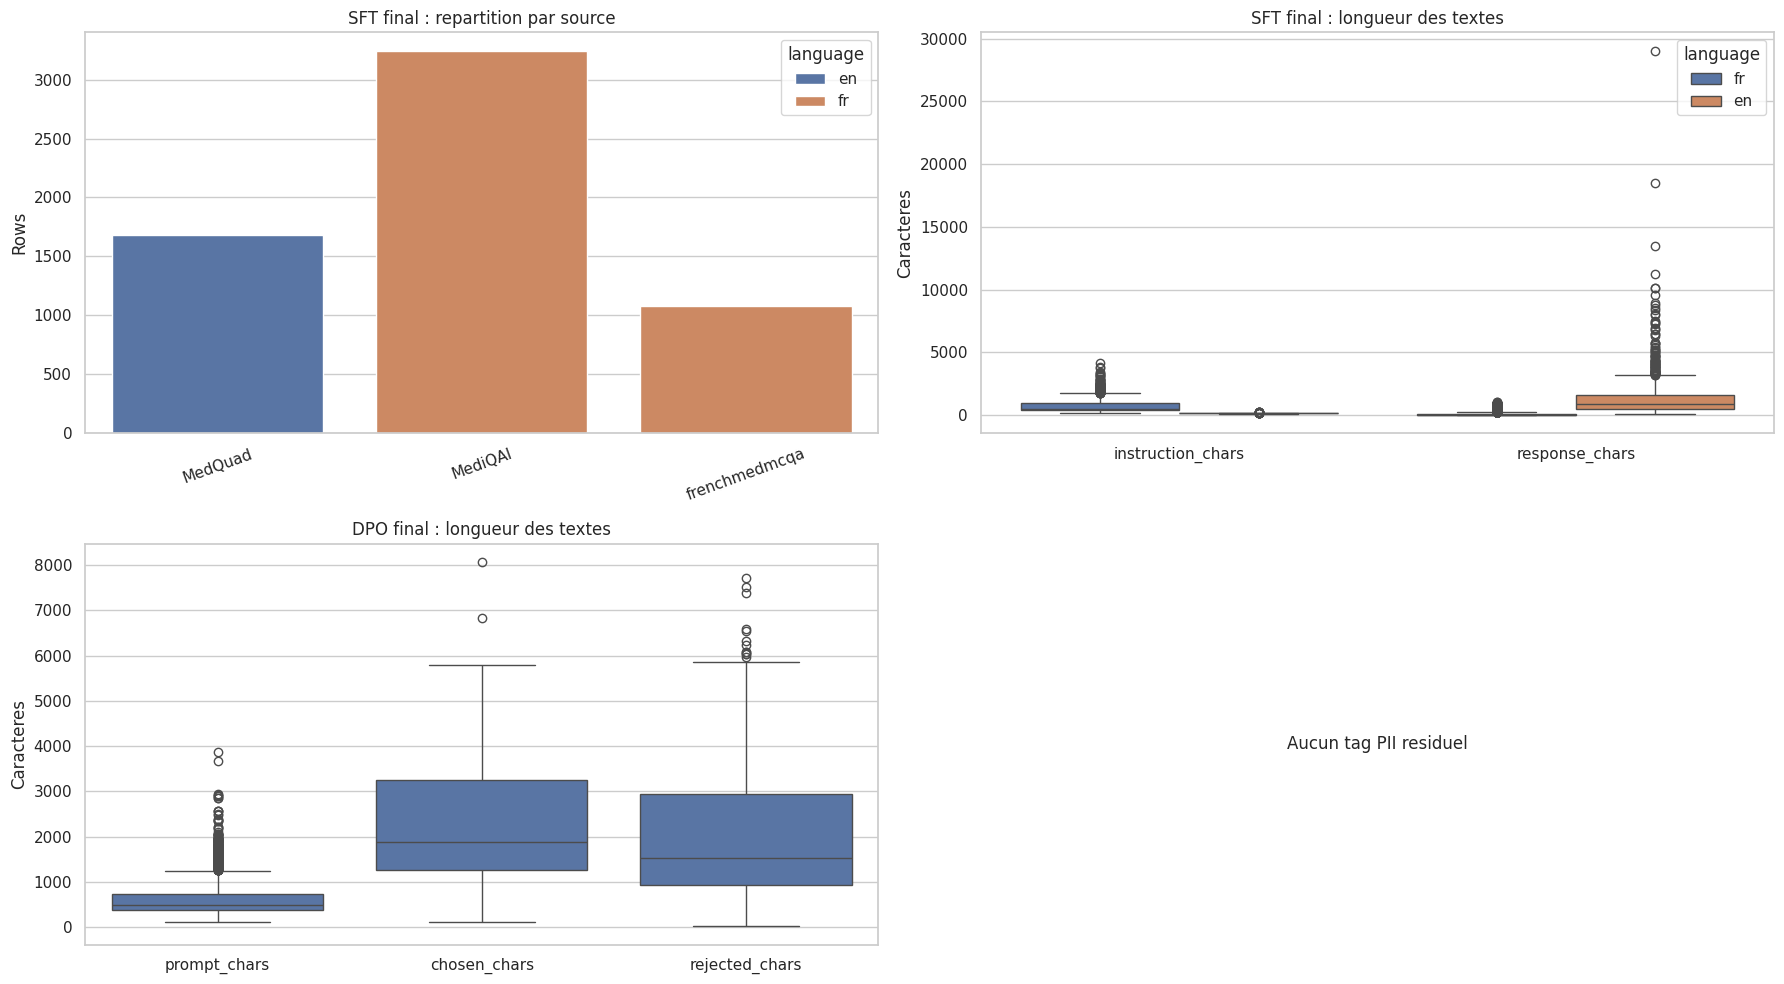

In [35]:
if sft_5000_df.empty and dpo_5000_df.empty:
    print("Aucun dataset final disponible pour les graphiques.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    if not sft_5000_df.empty:
        sft_mix_plot = sft_5000_df.groupby(["source_family", "language"]).size().reset_index(name="rows")
        sns.barplot(data=sft_mix_plot, x="source_family", y="rows", hue="language", ax=axes[0])
        axes[0].set_title("SFT final : repartition par source")
        axes[0].set_xlabel("")
        axes[0].set_ylabel("Rows")
        axes[0].tick_params(axis="x", rotation=20)
    else:
        axes[0].set_visible(False)

    if not sft_5000_df.empty:
        sft_lengths = sft_5000_df.assign(
            instruction_chars=sft_5000_df["instruction"].fillna("").str.len(),
            response_chars=sft_5000_df["response"].fillna("").str.len(),
        )
        sft_lengths_plot = sft_lengths.melt(
            id_vars=["language"],
            value_vars=["instruction_chars", "response_chars"],
            var_name="field",
            value_name="chars",
        )
        sns.boxplot(data=sft_lengths_plot, x="field", y="chars", hue="language", ax=axes[1])
        axes[1].set_title("SFT final : longueur des textes")
        axes[1].set_xlabel("")
        axes[1].set_ylabel("Caracteres")
    else:
        axes[1].set_visible(False)

    if not dpo_5000_df.empty:
        dpo_lengths = dpo_5000_df.assign(
            prompt_chars=dpo_5000_df["prompt"].fillna("").str.len(),
            chosen_chars=dpo_5000_df["chosen"].fillna("").str.len(),
            rejected_chars=dpo_5000_df["rejected"].fillna("").str.len(),
        )
        dpo_lengths_plot = dpo_lengths.melt(
            value_vars=["prompt_chars", "chosen_chars", "rejected_chars"],
            var_name="field",
            value_name="chars",
        )
        sns.boxplot(data=dpo_lengths_plot, x="field", y="chars", ax=axes[2])
        axes[2].set_title("DPO final : longueur des textes")
        axes[2].set_xlabel("")
        axes[2].set_ylabel("Caracteres")
    else:
        axes[2].set_visible(False)

    pii_plot = rgpd_report_df[rgpd_report_df["matches"] > 0].copy()
    if not pii_plot.empty:
        pii_plot = pii_plot.groupby("entity_type", as_index=False)["matches"].sum()
        sns.barplot(data=pii_plot, x="entity_type", y="matches", ax=axes[3])
        axes[3].set_title("PII residuel detecte apres anonymisation")
        axes[3].set_xlabel("")
        axes[3].set_ylabel("Occurrences")
    else:
        axes[3].text(0.5, 0.5, "Aucun tag PII residuel", ha="center", va="center", fontsize=12)
        axes[3].set_axis_off()

    plt.tight_layout()
    plt.show()


In [36]:
if schema_summary.empty:
    print("Aucun dataset disponible pour l'analyse.")
else:
    total_rows_known = schema_summary["num_rows"].dropna().sum()
    avg_cols = round(schema_summary["num_columns"].mean(), 2)
    print(f"Splits analyses         : {len(schema_summary)}")
    print(f"Lignes connues cumulees : {int(total_rows_known):,}".replace(",", " "))
    print(f"Colonnes moyennes/split : {avg_cols}")
    if not text_profile_df.empty:
        longest = text_profile_df.sort_values("avg_chars", ascending=False).iloc[0]
        print(
            "Colonne textuelle la plus longue en moyenne : "
            f"{longest['dataset']} / {longest['split']} / {longest['column']} ({longest['avg_chars']} chars)"
        )

Splits analyses         : 10
Lignes connues cumulees : 151 058
Colonnes moyennes/split : 8.7
Colonne textuelle la plus longue en moyenne : UltraMedicalPreference / validation / chosen (2900.55 chars)


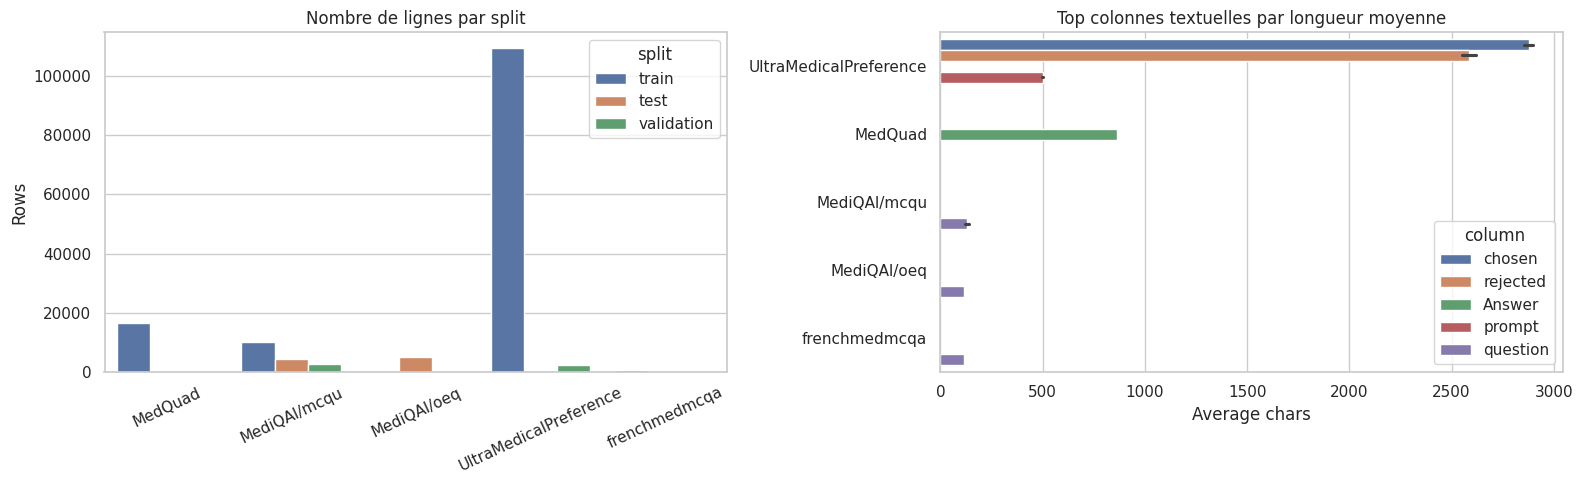

In [37]:
if not schema_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(
        data=schema_summary,
        x="dataset",
        y="num_rows",
        hue="split",
        ax=axes[0],
    )
    axes[0].set_title("Nombre de lignes par split")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=25)

    if not text_profile_df.empty:
        top_text = text_profile_df.sort_values("avg_chars", ascending=False).head(12)
        sns.barplot(
            data=top_text,
            x="avg_chars",
            y="dataset",
            hue="column",
            ax=axes[1],
        )
        axes[1].set_title("Top colonnes textuelles par longueur moyenne")
        axes[1].set_xlabel("Average chars")
        axes[1].set_ylabel("")
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

In [38]:
for (dataset_name, split_name), frame in samples.items():
    print(f"\n### {dataset_name} / {split_name}")
    if frame.empty:
        print("Aucun exemple echantillonne.")
        continue
    display(harmonize_sample_frame(dataset_name, frame).head(3))


### MediQAl/mcqu / train


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type,correct_answers_raw
0,7543,"Monsieur R. âgé de 37 ans, forestier de son métier, doit partir travailler pendant 2 ans au Gabon dans la région de ...",Au sujet des vaccinations :,Le vaccin contre la fièvre jaune est obligatoire,Le vaccin contre la fièvre jaune peut se faire au cabinet du médecin traitant,Le vaccin contre le choléra est un vaccin qui assure une protection supérieure à 80%,"Le vaccin contre l'hépatite B est conseillé mais il ne se trouve pas en pharmacie, il faut contacter l'hôpital",Les vaccinations contre le tétanos et la poliomyélite ne sont pas indispensables,A,QCU,Infectious Diseases,Understanding,A
1,10495,NaN,"Devant une tuméfaction cervicale médiane, juxta-hyoïdienne, qui ascensionne à la déglutition, quel diagnostic évoque...",Kyste dermoïde,Laryngocèle,Kyste du tractus thyréoglosse,Grenouillette sublinguale,Lithiase salivaire,C,QCU,Otorhinolaryngology (ENT),Understanding,C
2,17342,"Une jeune femme de 24 ans vous consulte pour asthénie, diarrhée, palpitations, sueurs. A l'examen, le pouls de repos...",Le traitement de cette patiente fait appel à :,Chirurgie en urgence,Iode radio-actif en urgence,Iode radio-actif en préparation à la chirurgie,Administration d'antithyroïdiens,Aucun de ces traitements,D,QCU,Endocrinology and Metabolism,Reasoning,D



### MediQAl/mcqu / validation


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type,correct_answers_raw
0,9940,NaN,L'amblyopie fonctionnelle se définit comme :,Une déviation des axes oculaires l'un par rapport à l'autre,Une paralysie de la motricité pupillaire,Une faible acuité visuelle sans cause organique décelable,Une perte du champ visuel périphérique,Aucune des définitions citées,C,QCU,Ophthalmology,Understanding,C
1,14132,NaN,"De 1967 à 1972, un groupe de 300 ouvriers exposés au moins cinq ans avant 1967 au disulfure de carbone a été suivi e...","0,1","0,2","1,5",5,6,D,QCU,Epidemiology,Reasoning,D
2,23706,NaN,(cochez la réponse fausse) Un syndrome confusionnel peut donner un tableau :,De la stupeur,De mutisme,D'agitation,De désorientation,De discordance,E,QCU,Psychiatry,Understanding,E



### MediQAl/mcqu / test


...

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?,"LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected roden..."
1,symptoms,What are the symptoms of Lymphocytic Choriomeningitis (LCM) ?,"LCMV is most commonly recognized as causing neurological disease, as its name implies, though infection without symp..."
2,susceptibility,Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?,"Individuals of all ages who come into contact with urine, feces, saliva, or blood of wild mice are potentially at ri..."



### UltraMedicalPreference / train


,prompt_id,label_type,prompt,chosen,rejected,metadata,feedback
0,"WikiInstruct,8304",length,"Investigate the intricacies of immunometabolism, a distinct subfield of immunology that examines the interconnection...","[{'content': 'Investigate the intricacies of immunometabolism, a distinct subfield of immunology that examines the i...","[{'content': 'Investigate the intricacies of immunometabolism, a distinct subfield of immunology that examines the i...","{'golden_answer': None, 'chosen': {'model': 'Mixtral-8x7B-Instruct', 'score': 5.0, 'rank': 1, 'evaluation': 'This re...","Assistant A provides a detailed and comprehensive response that thoroughly explains the concept of immunometabolism,..."
1,"WikiInstruct,8846",length,Examine the differential immunotoxic effects exerted by distinct microplastic polymer varieties on the innate and ad...,[{'content': 'Examine the differential immunotoxic effects exerted by distinct microplastic polymer varieties on the...,[{'content': 'Examine the differential immunotoxic effects exerted by distinct microplastic polymer varieties on the...,"{'golden_answer': None, 'chosen': {'model': 'Mixtral-8x7B-Instruct', 'score': 5.0, 'rank': 2, 'evaluation': 'This re...","Assistant A's response is well-structured, providing a detailed and comprehensive analysis of the immunotoxic effect..."
2,"MedMCQA,11404",length,"A lady comes with melanotic pigmentation of lip, presence of multiple polyps in the intestine, and a positive family...","[{'content': 'A lady comes with melanotic pigmentation of lip, presence of multiple polyps in the intestine, and a p...","[{'content': 'A lady comes with melanotic pigmentation of lip, presence of multiple polyps in the intestine, and a p...","{'golden_answer': 'A', 'chosen': {'model': 'Meta-Llama-3-70B-Instruct', 'score': 5.0, 'rank': 2, 'evaluation': 'The ...",Both Assistant A and Assistant B provided answers that correctly identified Peutz-Jeghers Syndrome as the most proba...



### UltraMedicalPreference / validation


,prompt_id,label_type,prompt,chosen,rejected,metadata,feedback
0,"MedQA,4303",hard,A 62-year-old Caucasian male presents to your office with hemoptysis and hematuria. On physical exam you note a sadd...,[{'content': 'A 62-year-old Caucasian male presents to your office with hemoptysis and hematuria. On physical exam y...,[{'content': 'A 62-year-old Caucasian male presents to your office with hemoptysis and hematuria. On physical exam y...,"{'golden_answer': 'C', 'chosen': {'model': 'gpt-4-1106-preview', 'score': 5.0, 'rank': 2, 'evaluation': 'The respons...",Both Assistant A and Assistant B provided responses that correctly identified corticosteroids as the most appropriat...
1,"MedQA-Evol,2307-synthetic-1",hard,"In a septuagenarian with hematochezia, obstipation, a history of febrile diverticulitis in the sigmoid colon, recent...","[{'content': 'In a septuagenarian with hematochezia, obstipation, a history of febrile diverticulitis in the sigmoid...","[{'content': 'In a septuagenarian with hematochezia, obstipation, a history of febrile diverticulitis in the sigmoid...","{'golden_answer': 'A', 'chosen': {'model': 'gpt-4-1106-preview', 'score': 5.0, 'rank': 1, 'evaluation': 'This respon...",Both Assistant A and Assistant B concluded that iron deficiency anemia (Option A) is the most likely cause of the pa...
2,"Medical-Instruct-120k,19736",length,I have been seeing a therapist for over a year. One did clinical therapy. I was doing better with her and able to sp...,[{'content': 'I have been seeing a therapist for over a year. One did clinical therapy. I was doing better with her ...,[{'content': 'I have been seeing a therapist for over a year. One did clinical therapy. I was doing better with her ...,"{'golden_answer': ' Hi, Thanks for using Chat Doctor. I have gone through your history. There are two treatment opt...","Upon reviewing the responses from Assistant A and Assistant B, several factors stand out in evaluating their effecti..."


## 7. Push des datasets SFT / DPO sur Hugging Face Hub

Pousse les jeux `sft_5000` et `dpo_5000` anonymisés sur le Hub pour les consommer ensuite depuis Google Colab avec Unsloth.

In [40]:
from huggingface_hub import login as hf_login


hf_login()

# ──────────────────────────────────────────────────────────────────────
HF_USERNAME = "Maphe"
# ──────────────────────────────────────────────────────────────────────

# Push SFT
sft_hub_id = f"{HF_USERNAME}/medical-sft-5k"
sft_5000_dataset.push_to_hub(sft_hub_id, private=True)
print(f"SFT pushed → https://huggingface.co/datasets/{sft_hub_id}")

# Push DPO
dpo_hub_id = f"{HF_USERNAME}/medical-dpo-5k"
dpo_5000_dataset.push_to_hub(dpo_hub_id, private=True)
print(f"DPO pushed → https://huggingface.co/datasets/{dpo_hub_id}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/762 [00:00<?, ?B/s]

DPO pushed → https://huggingface.co/datasets/Maphe/medical-dpo-5k
